In [1]:
import pandas as pd
from PIL import Image
import os
import sys
import json
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import f1_score

In [2]:
%matplotlib inline

# Pedestian - test-fog, test-night, test-town-01

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        "pedestrian.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [7]:
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [11]:
base_path = "C:/Users/Pratham Asaigoli/Machine_Learning_Safety"

image_paths_pedestrian = [
    f"{base_path}/assignment6/Data/test-fog/rgb-front/000350.jpg",
    f"{base_path}/assignment6/Data/test-night/rgb-front/000120.jpg",
    f"{base_path}/assignment6/Data/test-town-01/rgb-front/000210.jpg",
    # f"{base_path}/assignment6/Data/test/rgb-front/001680.jpg",
    # f"{base_path}/assignment6/Data/test/rgb-front/001850.jpg"
]

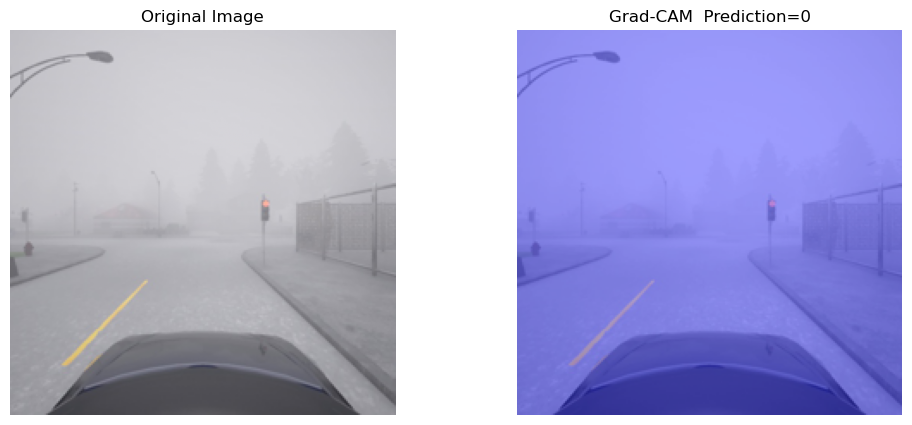

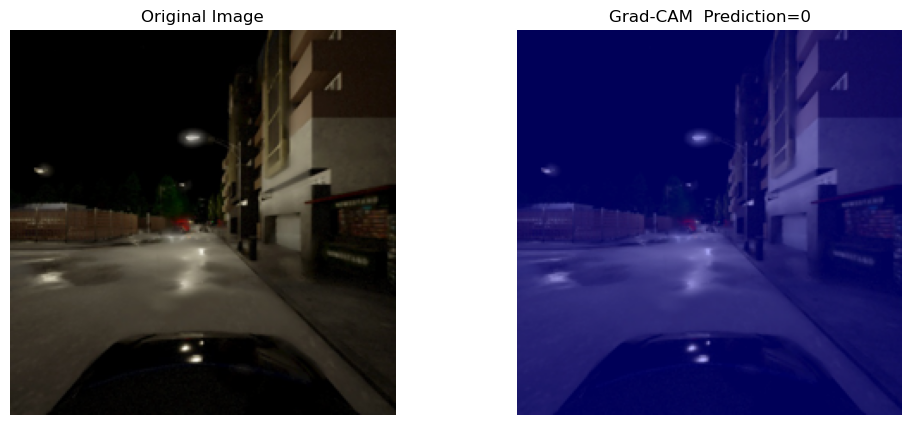

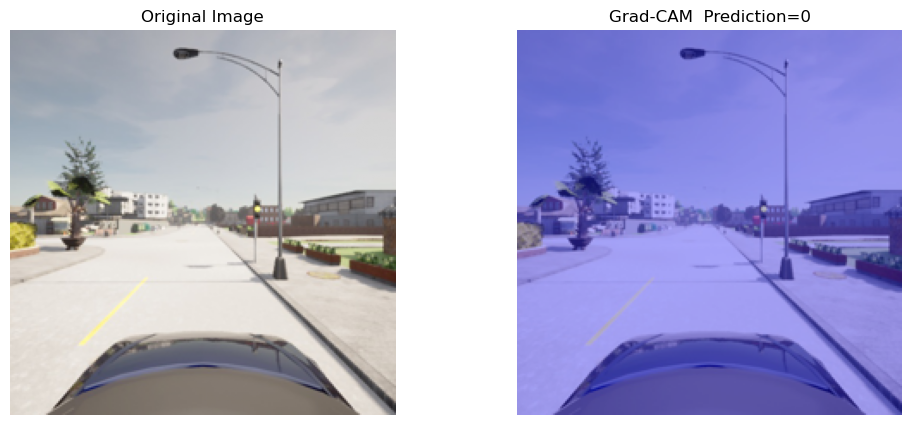

In [12]:
# ==========================
# 7. Generate Grad-CAM
# ==========================

for img_path in image_paths_pedestrian:

    image = Image.open(img_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)

    output = model(input_tensor)

    pred_prob = torch.sigmoid(output)

    pred_class = int(pred_prob > 0.5)

    targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_img = np.array(
        image.resize((224,224))
    ) / 255.0

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM  Prediction={pred_class}")
    plt.axis("off")

    plt.show()
    plt.close("all")

# Vehicle - test-fog, test-night, test-town-01

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vehicle = models.resnet18(weights=None)

model_vehicle.fc = nn.Linear(
    model_vehicle.fc.in_features,
    1
)

model_vehicle.load_state_dict(
    torch.load(
        "vehicle.pth",
        map_location=device
    )
)

model_vehicle.to(device)
model_vehicle.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [14]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [15]:
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [16]:
base_path = "C:/Users/Pratham Asaigoli/Machine_Learning_Safety"

image_paths_pedestrian = [
    f"{base_path}/assignment6/Data/test-fog/rgb-front/000350.jpg",
    f"{base_path}/assignment6/Data/test-night/rgb-front/000120.jpg",
    f"{base_path}/assignment6/Data/test-town-01/rgb-front/000210.jpg",
    # f"{base_path}/assignment6/Data/test/rgb-front/001680.jpg",
    # f"{base_path}/assignment6/Data/test/rgb-front/001850.jpg"
]

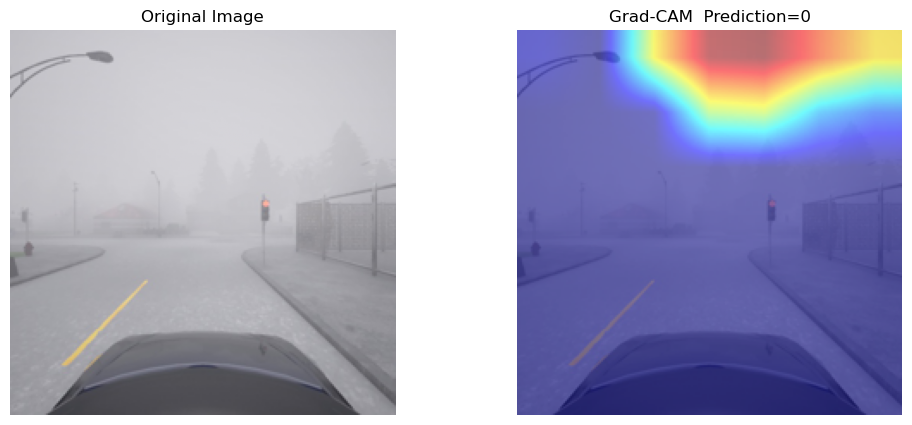

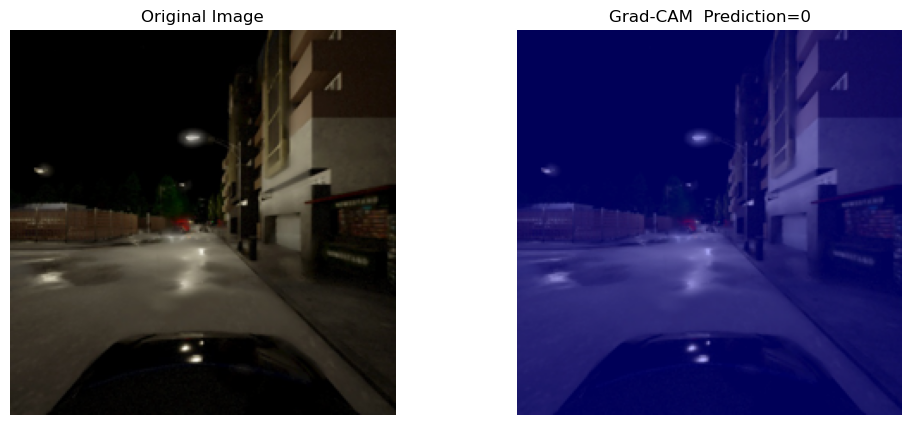

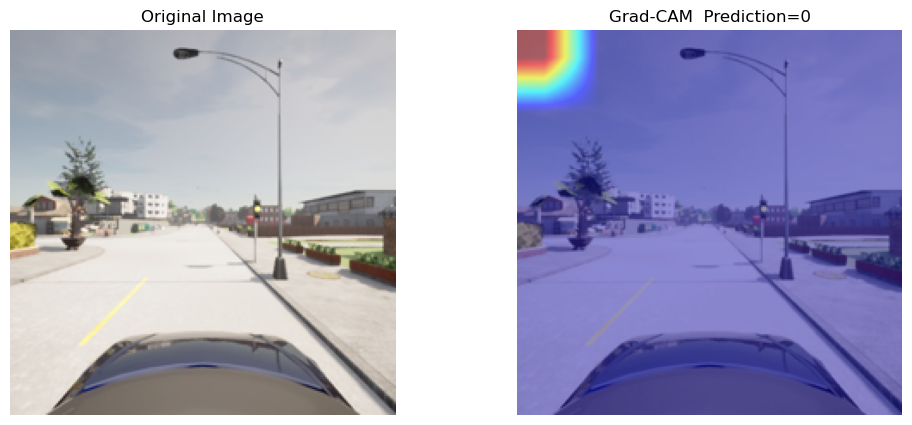

In [17]:
# ==========================
# 7. Generate Grad-CAM
# ==========================

for img_path in image_paths_pedestrian:

    image = Image.open(img_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)

    output = model(input_tensor)

    pred_prob = torch.sigmoid(output)

    pred_class = int(pred_prob > 0.5)

    targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_img = np.array(
        image.resize((224,224))
    ) / 255.0

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM  Prediction={pred_class}")
    plt.axis("off")

    plt.show()
    plt.close("all")

# Traffic - test-fog, test-night, test-town-01

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_traffic = models.resnet18(weights=None)

model_traffic.fc = nn.Linear(
    model_traffic.fc.in_features,
    1
)

model_traffic.load_state_dict(
    torch.load(
        "traffic.pth",
        map_location=device
    )
)

model_traffic.to(device)
model_traffic.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [19]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [20]:
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [23]:
base_path = "C:/Users/Pratham Asaigoli/Machine_Learning_Safety"

image_paths_traffic = [
    f"{base_path}/assignment6/Data/test-fog/rgb-front/000350.jpg",
    f"{base_path}/assignment6/Data/test-night/rgb-front/000120.jpg",
    f"{base_path}/assignment6/Data/test-town-01/rgb-front/000210.jpg",
    # f"{base_path}/assignment6/Data/test/rgb-front/001680.jpg",
    # f"{base_path}/assignment6/Data/test/rgb-front/001850.jpg"
]

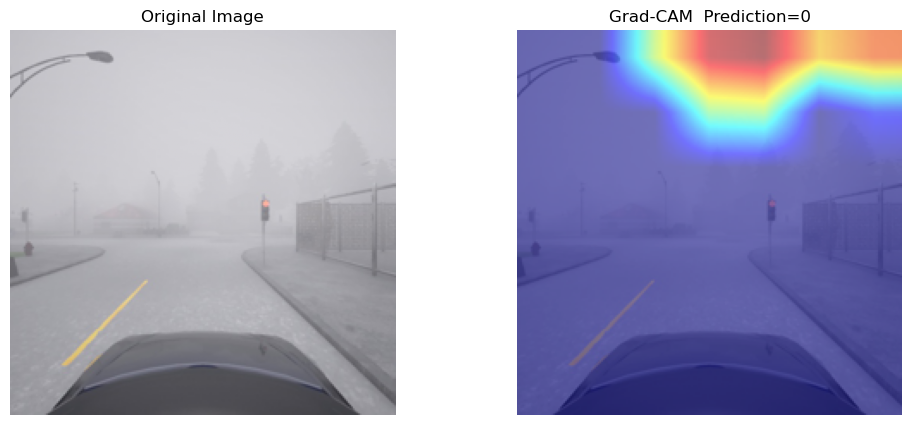

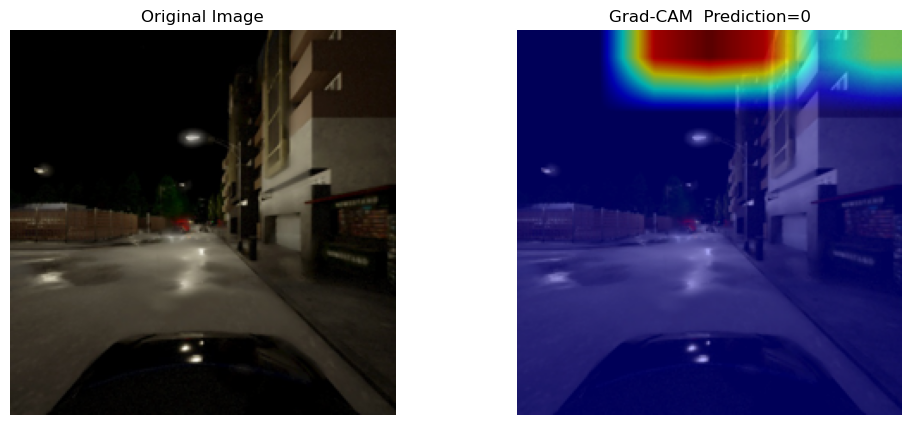

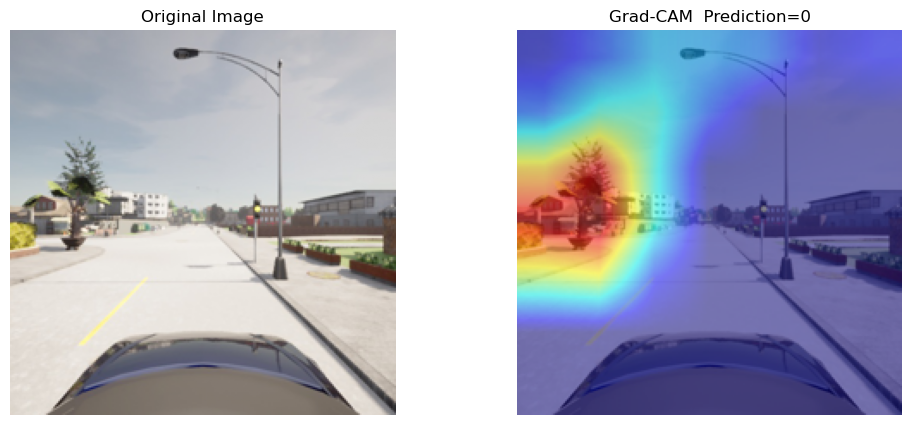

In [24]:
# ==========================
# 7. Generate Grad-CAM
# ==========================

for img_path in image_paths_traffic:

    image = Image.open(img_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)

    output = model(input_tensor)

    pred_prob = torch.sigmoid(output)

    pred_class = int(pred_prob > 0.5)

    targets = [ClassifierOutputTarget(0)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_img = np.array(
        image.resize((224,224))
    ) / 255.0

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM  Prediction={pred_class}")
    plt.axis("off")

    plt.show()

# Checking Accuracy

In [29]:
base_path = "C:/Users/Pratham Asaigoli/Machine_Learning_Safety/assignment6"

In [27]:
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import accuracy_score

def evaluate_binary_model(
    model,
    csv_path,
    image_folder,
    label_column,
    transform,
    device
):

    df = pd.read_csv(csv_path)

    y_true = []
    y_pred = []

    for _, row in df.iterrows():

        frame = str(row["frame"]).zfill(6)

        img_path = f"{image_folder}/{frame}.jpg"

        try:

            image = Image.open(img_path).convert("RGB")

            input_tensor = transform(image).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)

            pred = int(torch.sigmoid(output).item() > 0.5)

            y_true.append(int(row[label_column]))
            y_pred.append(pred)

        except:
            continue

    acc = accuracy_score(y_true, y_pred)

    return acc

In [37]:
# Pedestrian fog
ped_fog_acc = evaluate_binary_model(
    model=model,
    csv_path=f"{base_path}/Data/test-fog/labels.csv",
    image_folder=f"{base_path}/Data/test-fog/rgb-front",
    label_column="has_pedestrian",
    transform=transform,
    device=device
)
# Pedestrian night
ped_night_acc = evaluate_binary_model(
    model=model,
    csv_path=f"{base_path}/Data/test-night/labels.csv",
    image_folder=f"{base_path}/Data/test-night/rgb-front",
    label_column="has_pedestrian",
    transform=transform,
    device=device
)

# Pedestrian town
ped_town_acc = evaluate_binary_model(
    model=model,
    csv_path=f"{base_path}/Data/test-town-01/labels.csv",
    image_folder=f"{base_path}/Data/test-town-01/rgb-front",
    label_column="has_pedestrian",
    transform=transform,
    device=device
)

print("Pedestrian Fog Accuracy:", ped_fog_acc)
print("Pedestrian Night Accuracy:", ped_night_acc)
print("Pedestrian Town Accuracy:", ped_town_acc)

Pedestrian Fog Accuracy: 0.7958333333333333
Pedestrian Night Accuracy: 0.795
Pedestrian Town Accuracy: 0.8816666666666667


In [35]:
# Vehicle fog
veh_fog_acc = evaluate_binary_model(
    model=model_vehicle,
    csv_path=f"{base_path}/Data/test-fog/labels.csv",
    image_folder=f"{base_path}/Data/test-fog/rgb-front",
    label_column="has_vehicle",
    transform=transform,
    device=device
)
# Vehicle night
veh_night_acc = evaluate_binary_model(
    model=model_vehicle,
    csv_path=f"{base_path}/Data/test-night/labels.csv",
    image_folder=f"{base_path}/Data/test-night/rgb-front",
    label_column="has_vehicle",
    transform=transform,
    device=device
)
# Vehicle town
veh_town_acc = evaluate_binary_model(
    model=model_vehicle,
    csv_path=f"{base_path}/Data/test-town-01/labels.csv",
    image_folder=f"{base_path}/Data/test-town-01/rgb-front",
    label_column="has_vehicle",
    transform=transform,
    device=device
)

print("Vehicle Fog Accuracy:", veh_fog_acc)
print("Vehicle Night Accuracy:", veh_night_acc)
print("Vehicle Town Accuracy:", veh_town_acc)

Vehicle Fog Accuracy: 0.2263888888888889
Vehicle Night Accuracy: 0.2263888888888889
Vehicle Town Accuracy: 0.4027777777777778


In [39]:
# Traffic fog
traffic_fog_acc = evaluate_binary_model(
    model=model_traffic,
    csv_path=f"{base_path}/Data/test-fog/labels.csv",
    image_folder=f"{base_path}/Data/test-fog/rgb-front",
    label_column="has_traffic_light",
    transform=transform,
    device=device
)
# Traffic night
traffic_night_acc = evaluate_binary_model(
    model=model_traffic,
    csv_path=f"{base_path}/Data/test-night/labels.csv",
    image_folder=f"{base_path}/Data/test-night/rgb-front",
    label_column="has_traffic_light",
    transform=transform,
    device=device
)
# Traffic town
traffic_town_acc = evaluate_binary_model(
    model=model_traffic,
    csv_path=f"{base_path}/Data/test-town-01/labels.csv",
    image_folder=f"{base_path}/Data/test-town-01/rgb-front",
    label_column="has_traffic_light",
    transform=transform,
    device=device
)

print("Traffic Fog Accuracy:", traffic_fog_acc)
print("Traffic Night Accuracy:", traffic_night_acc)
print("Traffic Town Accuracy:", traffic_town_acc)

Traffic Fog Accuracy: 0.27166666666666667
Traffic Night Accuracy: 0.2725
Traffic Town Accuracy: 0.34


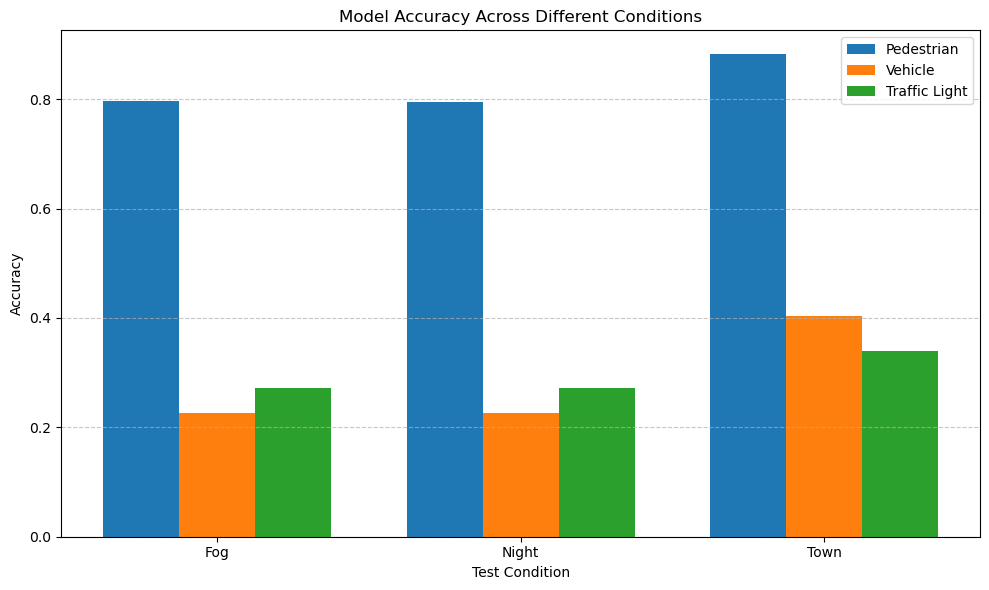

In [40]:
data = {
    "Condition": ["Fog", "Night", "Town"],
    
    "Pedestrian": [
        ped_fog_acc,
        ped_night_acc,
        ped_town_acc
    ],
    
    "Vehicle": [
        veh_fog_acc,
        veh_night_acc,
        veh_town_acc
    ],
    
    "Traffic Light": [
        traffic_fog_acc,
        traffic_night_acc,
        traffic_town_acc
    ]
}

df = pd.DataFrame(data)

# ==========================
# Plot
# ==========================

x = np.arange(len(df["Condition"]))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(
    x - width,
    df["Pedestrian"],
    width,
    label="Pedestrian"
)

plt.bar(
    x,
    df["Vehicle"],
    width,
    label="Vehicle"
)

plt.bar(
    x + width,
    df["Traffic Light"],
    width,
    label="Traffic Light"
)

plt.xticks(x, df["Condition"])

plt.ylabel("Accuracy")
plt.xlabel("Test Condition")
plt.title("Model Accuracy Across Different Conditions")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()